In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
from cfb_upsets.features import add_features

df = pd.read_csv("../data/processed/games_clean_all.csv")
df = add_features(df)
df_model = df.dropna(subset=["upset"]).copy()

In [2]:
feature_cols = ["spread_magnitude", "is_home_underdog", "elo_diff", "rolling_win_pct_diff", "week"]

# One-hot encode conference separately, since it's categorical
conf_dummies = pd.get_dummies(df_model["underdog_conference"], prefix="conf")

X = pd.concat([df_model[feature_cols], conf_dummies], axis=1)
y = df_model["upset"]

train_mask = df_model["season"] <= 2024
test_mask = df_model["season"] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {len(X_train)} games (2021-2024)")
print(f"Test:  {len(X_test)} games (2025)")

Train: 3134 games (2021-2024)
Test:  808 games (2025)


In [3]:
baseline_predictions = np.zeros(len(y_test))  # 0 = favorite wins, our "always predict favorite" baseline
baseline_accuracy = (baseline_predictions == y_test).mean()

print(f"Baseline accuracy (always predict favorite wins): {baseline_accuracy:.1%}")

Baseline accuracy (always predict favorite wins): 73.5%


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

logreg_preds = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_preds)

print(f"Logistic Regression accuracy: {logreg_accuracy:.1%}")

Logistic Regression accuracy: 73.3%


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print(f"Random Forest accuracy: {rf_accuracy:.1%}")

Random Forest accuracy: 73.4%


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

print("Logistic Regression:")
print(confusion_matrix(y_test, logreg_preds))
print(classification_report(y_test, logreg_preds))

print("\nRandom Forest:")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Logistic Regression:
[[583  11]
 [205   9]]
              precision    recall  f1-score   support

         0.0       0.74      0.98      0.84       594
         1.0       0.45      0.04      0.08       214

    accuracy                           0.73       808
   macro avg       0.59      0.51      0.46       808
weighted avg       0.66      0.73      0.64       808


Random Forest:
[[593   1]
 [214   0]]
              precision    recall  f1-score   support

         0.0       0.73      1.00      0.85       594
         1.0       0.00      0.00      0.00       214

    accuracy                           0.73       808
   macro avg       0.37      0.50      0.42       808
weighted avg       0.54      0.73      0.62       808



In [7]:
logreg_probs = logreg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

print("Logistic regression predicted probabilities - summary:")
print(pd.Series(logreg_probs).describe())

Logistic regression predicted probabilities - summary:
count    808.000000
mean       0.285531
std        0.147553
min        0.003505
25%        0.161328
50%        0.311021
75%        0.415974
max        0.572658
dtype: float64


In [8]:
calibration_df = pd.DataFrame({
    "predicted_prob": logreg_probs,
    "actual_upset": y_test.values
})

calibration_df["prob_bucket"] = pd.qcut(calibration_df["predicted_prob"], q=5)

calibration_check = calibration_df.groupby("prob_bucket")["actual_upset"].agg(["mean", "count"])
print(calibration_check)

                      mean  count
prob_bucket                      
(0.00251, 0.129]  0.055556    162
(0.129, 0.255]    0.186335    161
(0.255, 0.351]    0.296296    162
(0.351, 0.433]    0.354037    161
(0.433, 0.573]    0.432099    162


In [9]:
from sklearn.metrics import brier_score_loss

# Baseline 1: naive constant prediction (just the overall training upset rate, no info used)
naive_baseline_probs = np.full(len(y_test), y_train.mean())
naive_brier = brier_score_loss(y_test, naive_baseline_probs)

# Baseline 2: market-only model (spread_magnitude alone, nothing else)
from sklearn.linear_model import LogisticRegression
market_only = LogisticRegression(max_iter=1000)
market_only.fit(X_train[["spread_magnitude"]], y_train)
market_only_probs = market_only.predict_proba(X_test[["spread_magnitude"]])[:, 1]
market_brier = brier_score_loss(y_test, market_only_probs)

# Your full model
logreg_brier = brier_score_loss(y_test, logreg_probs)

print(f"Naive baseline Brier score:     {naive_brier:.4f}")
print(f"Market-only (spread) Brier:     {market_brier:.4f}")
print(f"Full logistic regression Brier: {logreg_brier:.4f}")

Naive baseline Brier score:     0.1948
Market-only (spread) Brier:     0.1754
Full logistic regression Brier: 0.1763


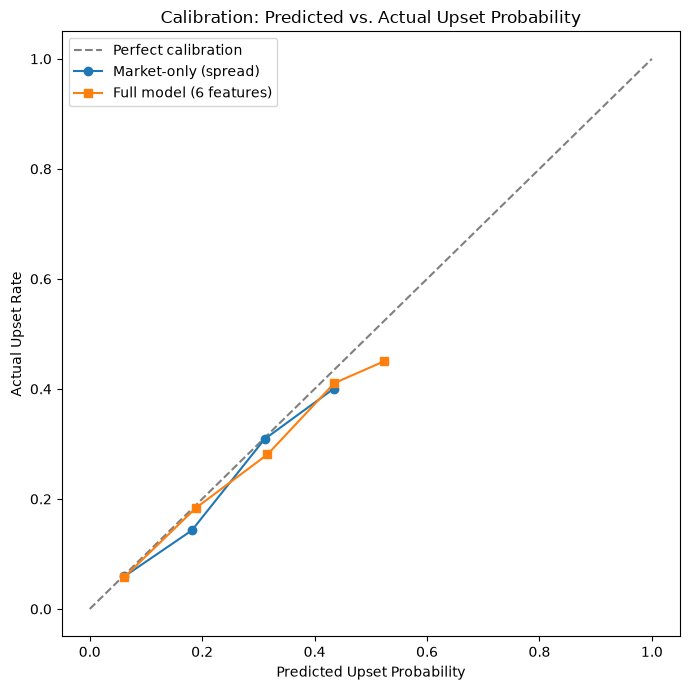

In [10]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 7))

prob_true_market, prob_pred_market = calibration_curve(y_test, market_only_probs, n_bins=8)
prob_true_full, prob_pred_full = calibration_curve(y_test, logreg_probs, n_bins=8)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(prob_pred_market, prob_true_market, marker="o", label="Market-only (spread)")
ax.plot(prob_pred_full, prob_true_full, marker="s", label="Full model (6 features)")

ax.set_xlabel("Predicted Upset Probability")
ax.set_ylabel("Actual Upset Rate")
ax.set_title("Calibration: Predicted vs. Actual Upset Probability")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_plot.png", dpi=150)
plt.show()

In [11]:
np.random.seed(42)

n_simulations = 10000
probs = market_only_probs  # use the market-only model's probabilities as "true" per-game upset probability

simulated_upset_counts = []

for _ in range(n_simulations):
    simulated_outcomes = np.random.binomial(1, probs)  # one coin flip per game, using that game's true probability
    simulated_upset_counts.append(simulated_outcomes.sum())

simulated_upset_counts = np.array(simulated_upset_counts)

actual_upset_count = y_test.sum()

print(f"Actual 2025 upset count: {int(actual_upset_count)}")
print(f"Simulated mean upset count: {simulated_upset_counts.mean():.1f}")
print(f"Simulated std dev: {simulated_upset_counts.std():.1f}")
print(f"Simulated 5th-95th percentile range: {np.percentile(simulated_upset_counts, 5):.0f} - {np.percentile(simulated_upset_counts, 95):.0f}")

Actual 2025 upset count: 214
Simulated mean upset count: 230.5
Simulated std dev: 12.1
Simulated 5th-95th percentile range: 211 - 250


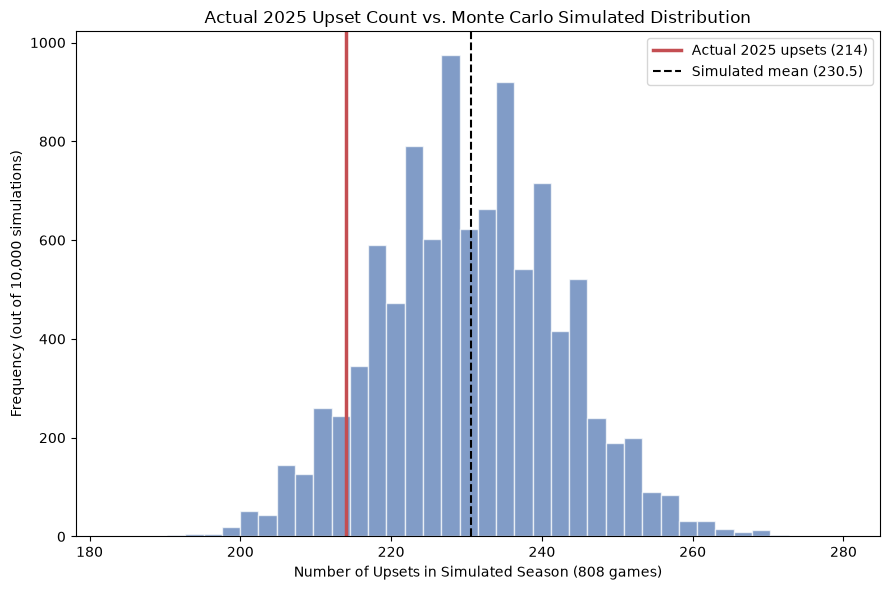

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(simulated_upset_counts, bins=40, color="#4C72B0", alpha=0.7, edgecolor="white")
ax.axvline(actual_upset_count, color="#C44E52", linewidth=2.5, label=f"Actual 2025 upsets ({int(actual_upset_count)})")
ax.axvline(simulated_upset_counts.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Simulated mean ({simulated_upset_counts.mean():.1f})")

ax.set_xlabel("Number of Upsets in Simulated Season (808 games)")
ax.set_ylabel("Frequency (out of 10,000 simulations)")
ax.set_title("Actual 2025 Upset Count vs. Monte Carlo Simulated Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/monte_carlo_upset_distribution.png", dpi=150)
plt.show()

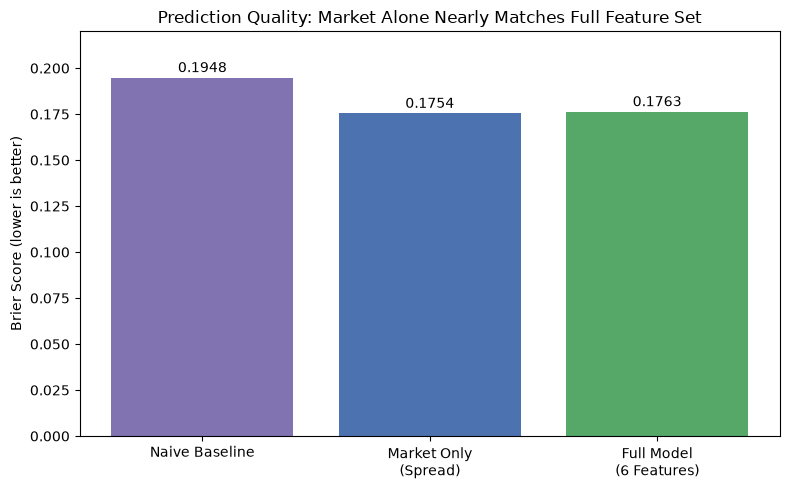

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Naive Baseline", "Market Only\n(Spread)", "Full Model\n(6 Features)"]
scores = [naive_brier, market_brier, logreg_brier]
colors = ["#8172B2", "#4C72B0", "#55A868"]

bars = ax.bar(labels, scores, color=colors)
ax.set_ylabel("Brier Score (lower is better)")
ax.set_title("Prediction Quality: Market Alone Nearly Matches Full Feature Set")
ax.set_ylim(0, 0.22)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.003, f"{score:.4f}", ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/brier_score_comparison.png", dpi=150)
plt.show()

In [14]:
demo_df = df_model[test_mask].copy()
demo_df["predicted_prob"] = logreg_probs
demo_df["predicted_upset"] = (demo_df["predicted_prob"] >= 0.5).astype(int)

display_cols = ["homeTeam", "awayTeam", "spread", "favorite", "predicted_prob", "upset"]

# A correctly predicted upset (rare and interesting -- the model was genuinely confident)
caught_upset = demo_df[(demo_df["upset"] == 1) & (demo_df["predicted_prob"] > 0.4)].sort_values("predicted_prob", ascending=False)

# A missed upset (model was confident in the favorite, underdog won anyway -- shows the randomness)
missed_upset = demo_df[(demo_df["upset"] == 1) & (demo_df["predicted_prob"] < 0.15)].sort_values("predicted_prob")

# A correctly predicted favorite win (the boring, common case)
correct_favorite = demo_df[(demo_df["upset"] == 0) & (demo_df["predicted_prob"] < 0.15)].sort_values("predicted_prob")

print("Model flagged elevated upset risk, and the underdog won:")
print(caught_upset[display_cols].head(3))

print("\nModel was confident in the favorite, but the underdog won anyway (illustrates irreducible randomness):")
print(missed_upset[display_cols].head(3))

print("\nModel correctly predicted a routine favorite win:")
print(correct_favorite[display_cols].head(3))

Model flagged elevated upset risk, and the underdog won:
            homeTeam          awayTeam  spread favorite  predicted_prob  upset
3237         Arizona      Kansas State     1.5     away        0.572658    1.0
3591  Arkansas State  Georgia Southern     1.0     away        0.554598    1.0
3856       App State    Arkansas State    -1.0     home        0.537521    1.0

Model was confident in the favorite, but the underdog won anyway (illustrates irreducible randomness):
        homeTeam      awayTeam  spread favorite  predicted_prob  upset
3529         UAB       Memphis    23.5     away        0.050736    1.0
3414        UCLA    Penn State    24.5     away        0.060252    1.0
3460  Penn State  Northwestern   -20.5     home        0.070170    1.0

Model correctly predicted a routine favorite win:
        homeTeam    awayTeam  spread favorite  predicted_prob  upset
3191  Texas Tech  Kent State   -48.5     home        0.003505    0.0
3778     Georgia   Charlotte   -42.5     home     

In [1]:
from numpy.random import Generator, PCG64, MT19937

def run_monte_carlo(rng, probs, n_simulations=10000):
    counts = []
    for _ in range(n_simulations):
        outcomes = rng.binomial(1, probs)
        counts.append(outcomes.sum())
    return np.array(counts)

# Run 1: PCG64 (NumPy's modern default), seed 42
rng_pcg64 = Generator(PCG64(42))
counts_pcg64 = run_monte_carlo(rng_pcg64, market_only_probs)

# Run 2: PCG64, different seed -- checks seed-dependence
rng_pcg64_seed2 = Generator(PCG64(123))
counts_pcg64_seed2 = run_monte_carlo(rng_pcg64_seed2, market_only_probs)

# Run 3: Mersenne Twister (older, different algorithm family entirely) -- checks generator-dependence
rng_mt19937 = Generator(MT19937(42))
counts_mt19937 = run_monte_carlo(rng_mt19937, market_only_probs)

print(f"Actual 2025 upsets: {int(actual_upset_count)}")
print(f"PCG64 (seed=42):    mean={counts_pcg64.mean():.1f}, std={counts_pcg64.std():.1f}")
print(f"PCG64 (seed=123):   mean={counts_pcg64_seed2.mean():.1f}, std={counts_pcg64_seed2.std():.1f}")
print(f"MT19937 (seed=42):  mean={counts_mt19937.mean():.1f}, std={counts_mt19937.std():.1f}")

NameError: name 'market_only_probs' is not defined